# Evenly Discretised Magnitude-Frequency Distribution (MFD)
The typologies of [Magnitude-Frequency Distribution (MFD)](https://gemsciencetools.github.io/quakeT/contents/glossary.html#term-MagnitudeFrequency-Distribution-MFD) supported by the OQ Engine are available in this [folder](https://github.com/gem/oq-engine/tree/master/openquake/hazardlib/mfd). A description of these distributions is available [here](https://docs.openquake.org/oq-engine/3.25/manual/user-guide/inputs/seismic-source-model-inputs.html#magnitude-frequency-distributions). 

The main models supported are:
- Double Truncated MFD
- Evenly Spaced MFD
- Arbitrary MFD
- Tapered MFD
- Youngs and Coppersmith MFD

In this notebook, we briefly show how you can utilize evenly discretised MFD as an example.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from openquake.hazardlib.mfd import EvenlyDiscretizedMFD

For `EvenlyDiscretizedMFD`, you need magnitudes, magnitude step, and rates for each magnitude as requirements.

In [2]:
magnitude_step = 0.2
magnitudes = np.arange(4.1, 7.0, magnitude_step)
rates = np.random.rand(magnitudes.size)

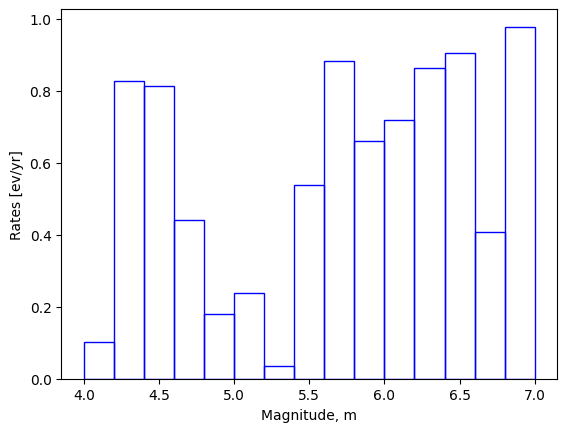

In [3]:
# Histogram plot 
_ = plt.bar(magnitudes, rates, width=magnitude_step, fc='none', ec='blue')
_ = plt.xlabel('Magnitude, m')
_ = plt.ylabel('Rates [ev/yr]')

In [4]:
# Create the Evenly Discretised MFD
mfd = EvenlyDiscretizedMFD(min(magnitudes), magnitude_step, rates)

Each magnitude-frequency available in the OQ Engine offers a number of default methods including:
- `check_constraints`: controls the instantiation of the MFD based on the information provided,
- `get_annual_occurrence_rates`: returns a list of tuples, each one containing a magnitude and the corresponding rate, 
- `get_min_max_mag`: returns the minimum and maximum magnitudes,
- `modify_set_mfd`:  applies absolute modification of the MFD from the min_mag, bin_width, and occurrence_rates modification.

In [5]:
mocc = mfd.get_annual_occurrence_rates()

In [6]:
mags = np.array([m[0] for m in mocc]) 
rtes = np.array([m[1] for m in mocc]) 

In [7]:
df_mocc = pd.DataFrame({
    "Magnitudes": mags,
    "Rates": rtes
})
display(df_mocc)

,Magnitudes,Rates
0,4.1,0.102031
1,4.3,0.826247
2,4.5,0.812529
3,4.7,0.441247
4,4.9,0.181112
5,5.1,0.238289
6,5.3,0.034432
7,5.5,0.537567
8,5.7,0.882729
9,5.9,0.660822
